# Notebook 02 — Exploratory Data Analysis (EDA)

**Purpose:** Explore the merged dataset visually before any modelling.
All figures generated here are saved to `outputs/figures/`.

**Figures produced:**
- Fig 4.1 — Class Distribution (HAM vs SPAM)
- Fig 4.2 — Word Cloud: Fraudulent Messages
- Fig 4.3 — Word Cloud: Legitimate Messages
- Fig 4.4 — Message Length Distribution
- Fig 4.5 — Top 20 Most Frequent Words per Class

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

sys.path.append(os.path.abspath('..'))

# Plot styling
plt.rcParams.update({
    'font.family':  'Times New Roman',
    'font.size':    12,
    'figure.dpi':   150,
})

FIGURES_DIR = '../outputs/figures/'
os.makedirs(FIGURES_DIR, exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


In [2]:
# ── Load processed dataset ────────────────────────────────────────────────────
df = pd.read_csv('../data/processed/cleaned_dataset.csv')
print(f'Dataset loaded: {len(df)} messages')
print(f'Columns: {list(df.columns)}')
df.head(3)

Dataset loaded: 3903 messages
Columns: ['label', 'label_str', 'message', 'sender', 'direction', 'timestamp']


,label,label_str,message,sender,direction,timestamp
0,1,SPAM,CANCLE,127,send,04/09/2014 08:29
1,1,SPAM,Your plan Smallie.is going to be renewed. Plea...,127,receive,04/09/2014 08:25
2,1,SPAM,"Dear Glo subscriber, you just passed 80% of yo...",127,receive,04/09/2014 08:25


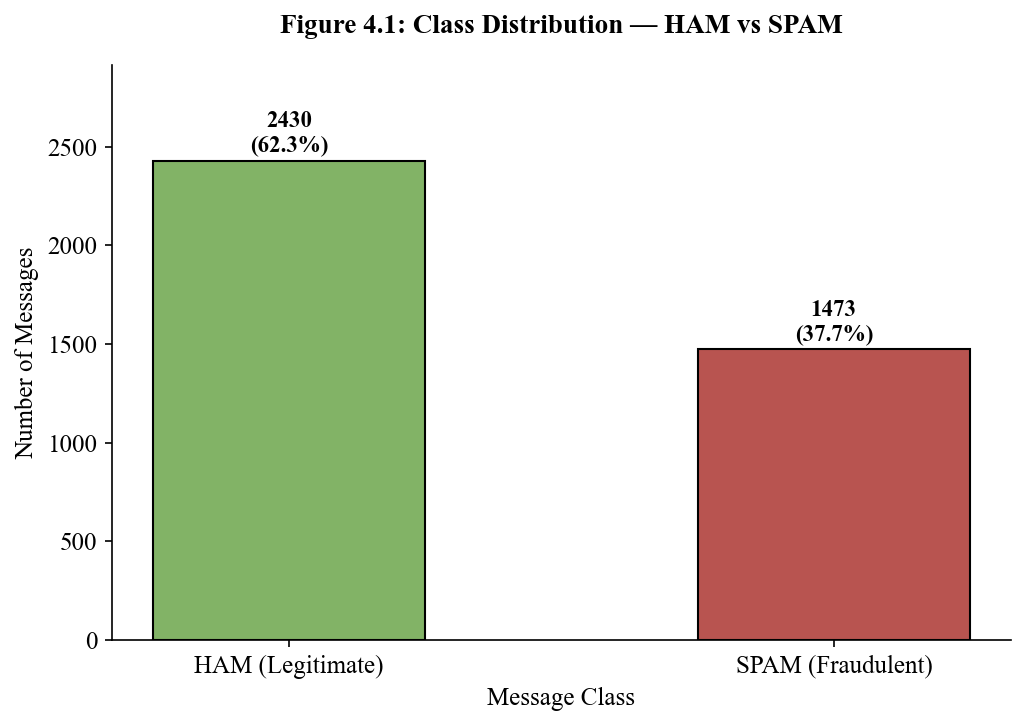

Saved: fig4_1_class_distribution.png


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# FIG 4.1 — Class Distribution
# ══════════════════════════════════════════════════════════════════════════════
counts = df['label_str'].value_counts()
ham_count  = counts.get('HAM',  0)
spam_count = counts.get('SPAM', 0)
total      = len(df)

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    ['HAM (Legitimate)', 'SPAM (Fraudulent)'],
    [ham_count, spam_count],
    color=['#82b366', '#b85450'],
    edgecolor='black',
    width=0.5
)

for bar, count in zip(bars, [ham_count, spam_count]):
    pct = count / total * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f'{count}\n({pct:.1f}%)',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

ax.set_title('Figure 4.1: Class Distribution — HAM vs SPAM',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Number of Messages', fontsize=12)
ax.set_xlabel('Message Class', fontsize=12)
ax.set_ylim(0, max(ham_count, spam_count) * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR + 'fig4_1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig4_1_class_distribution.png')

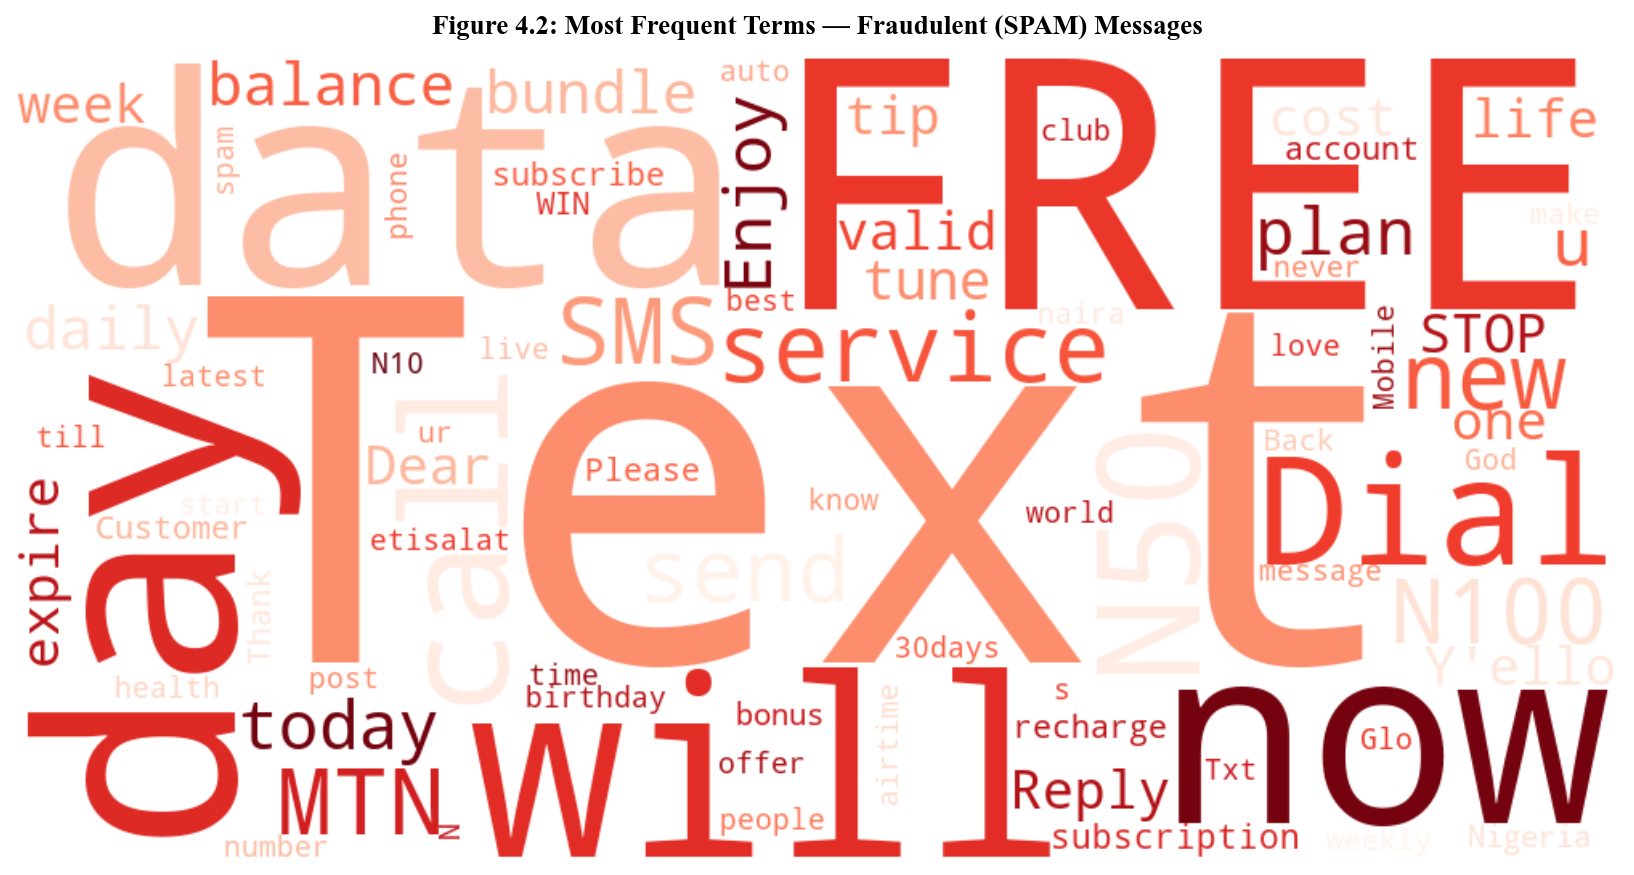

Saved: fig4_2_wordcloud_spam.png


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# FIG 4.2 — Word Cloud: Fraudulent (SPAM) Messages
# ══════════════════════════════════════════════════════════════════════════════
spam_text = ' '.join(df[df['label'] == 1]['message'].dropna().astype(str))

wc_spam = WordCloud(
    width=1000, height=500,
    background_color='white',
    colormap='Reds',
    max_words=80,
    collocations=False,
    min_font_size=10
).generate(spam_text)

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(wc_spam, interpolation='bilinear')
ax.axis('off')
ax.set_title('Figure 4.2: Most Frequent Terms — Fraudulent (SPAM) Messages',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'fig4_2_wordcloud_spam.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig4_2_wordcloud_spam.png')

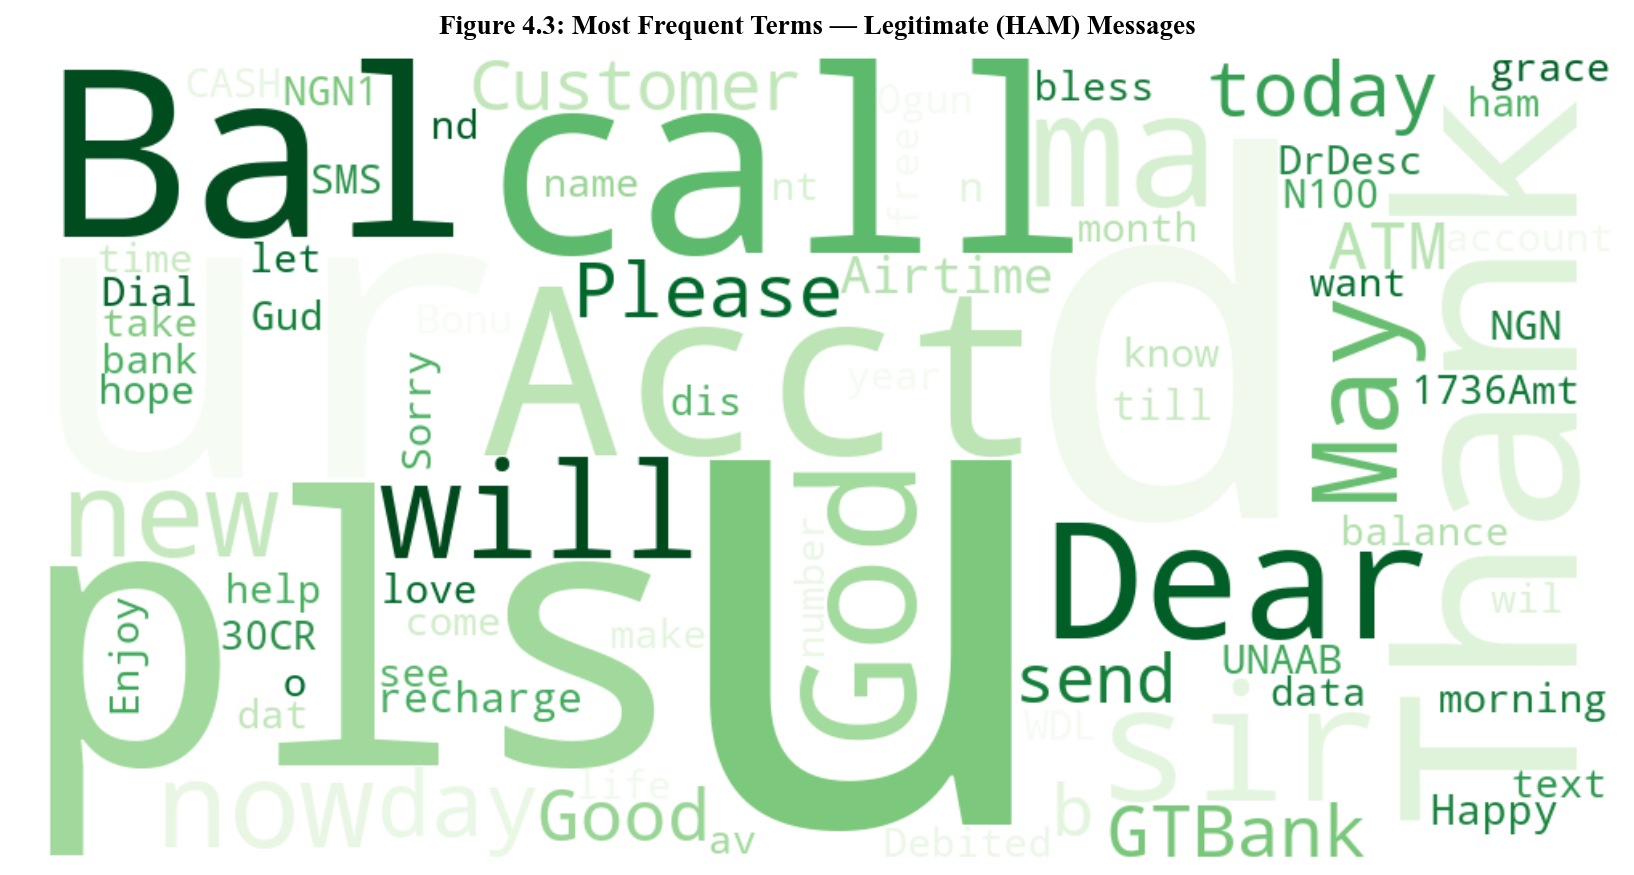

Saved: fig4_3_wordcloud_ham.png


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# FIG 4.3 — Word Cloud: Legitimate (HAM) Messages
# ══════════════════════════════════════════════════════════════════════════════
ham_text = ' '.join(df[df['label'] == 0]['message'].dropna().astype(str))

wc_ham = WordCloud(
    width=1000, height=500,
    background_color='white',
    colormap='Greens',
    max_words=80,
    collocations=False,
    min_font_size=10
).generate(ham_text)

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(wc_ham, interpolation='bilinear')
ax.axis('off')
ax.set_title('Figure 4.3: Most Frequent Terms — Legitimate (HAM) Messages',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'fig4_3_wordcloud_ham.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig4_3_wordcloud_ham.png')

C:\Users\onahe\AppData\Local\Temp\ipykernel_19912\1106120669.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(


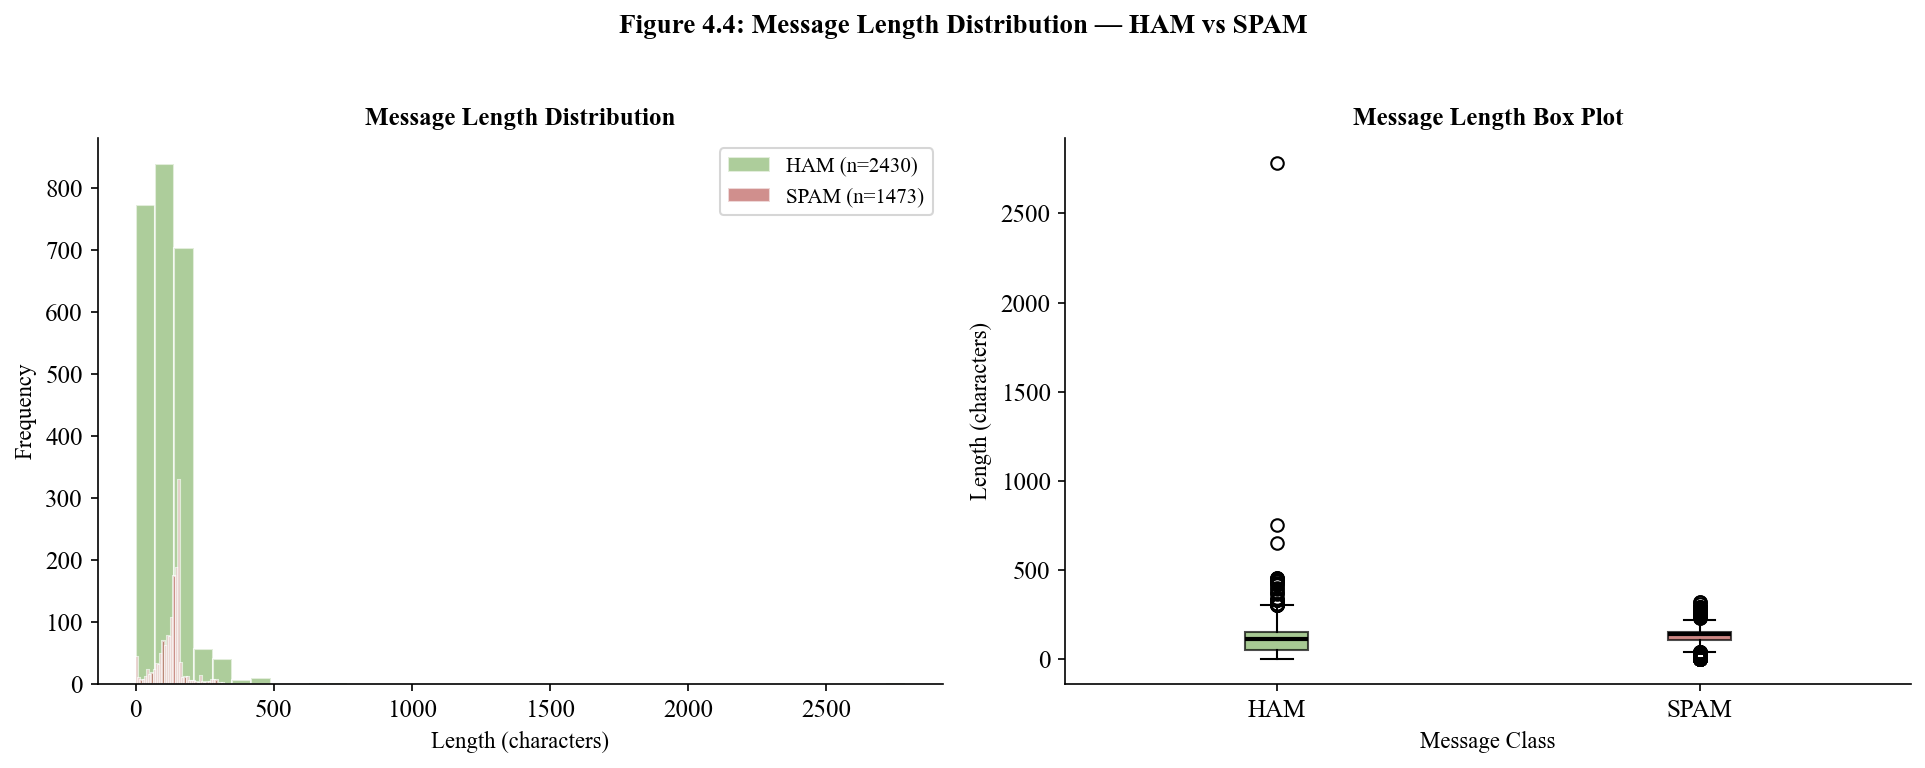

Saved: fig4_4_message_length.png

Message Length Statistics:
            count   mean   std  min    25%    50%    75%     max
label_str                                                       
HAM        2430.0  110.0  87.4  1.0   53.0  114.0  153.0  2784.0
SPAM       1473.0  130.1  46.9  1.0  110.0  140.0  156.0   320.0


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# FIG 4.4 — Message Length Distribution
# ══════════════════════════════════════════════════════════════════════════════
df['msg_len'] = df['message'].astype(str).str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
for lbl, colour, name in [(0,'#82b366','HAM'), (1,'#b85450','SPAM')]:
    subset = df[df['label'] == lbl]['msg_len']
    axes[0].hist(
        subset, bins=40, alpha=0.65,
        color=colour, label=f'{name} (n={len(subset)})',
        edgecolor='white'
    )

axes[0].set_title('Message Length Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Length (characters)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Box plot
bp_data  = [df[df['label']==0]['msg_len'], df[df['label']==1]['msg_len']]
bp = axes[1].boxplot(
    bp_data,
    labels=['HAM', 'SPAM'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)
bp['boxes'][0].set_facecolor('#82b366')
bp['boxes'][1].set_facecolor('#b85450')
for patch in bp['boxes']:
    patch.set_alpha(0.7)

axes[1].set_title('Message Length Box Plot', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Message Class', fontsize=11)
axes[1].set_ylabel('Length (characters)', fontsize=11)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle('Figure 4.4: Message Length Distribution — HAM vs SPAM',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'fig4_4_message_length.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig4_4_message_length.png')

# Summary stats
print('\nMessage Length Statistics:')
print(df.groupby('label_str')['msg_len'].describe().round(1))

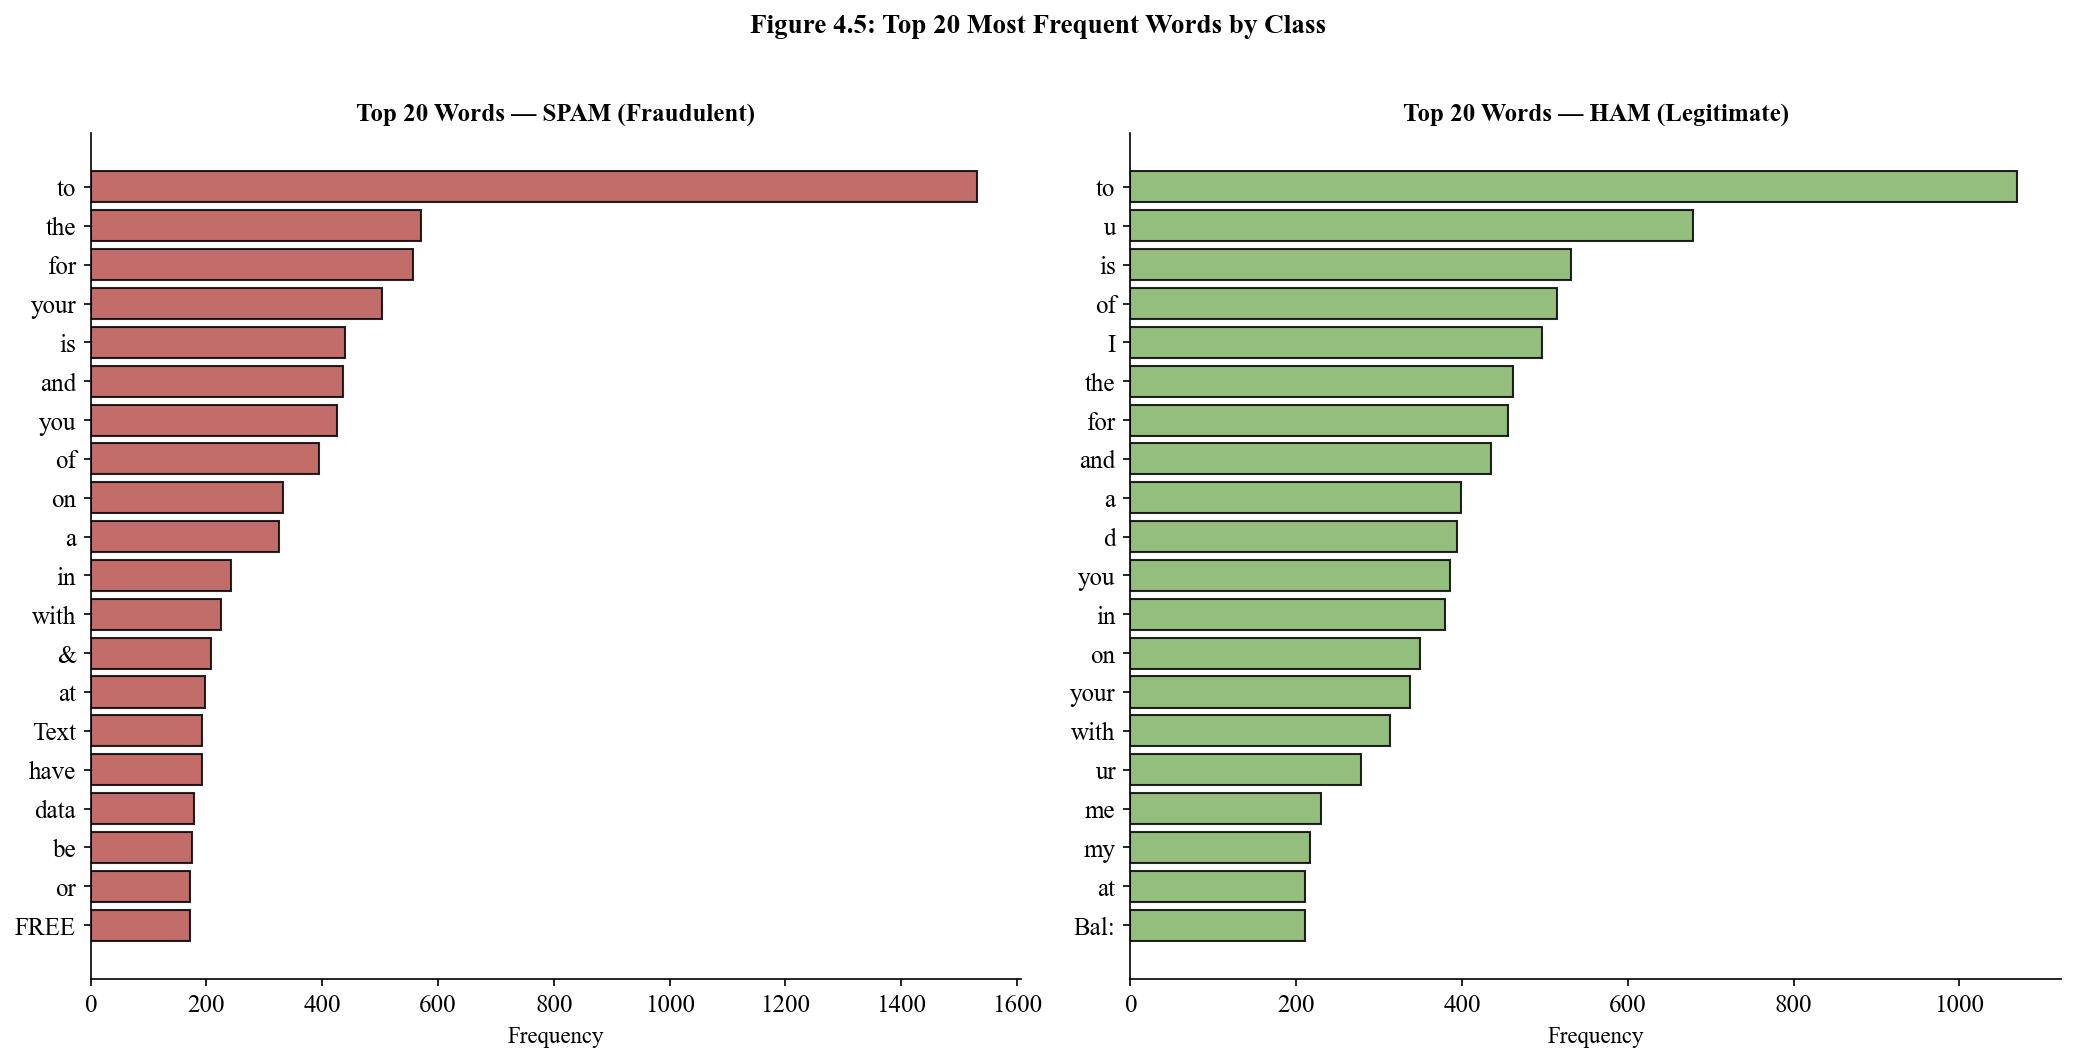

Saved: fig4_5_top_words.png


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# FIG 4.5 — Top 20 Most Frequent Words per Class
# ══════════════════════════════════════════════════════════════════════════════
def top_words(text_series, n=20):
    all_words = ' '.join(text_series.dropna().astype(str)).split()
    counter   = Counter(all_words)
    return pd.DataFrame(counter.most_common(n), columns=['word', 'count'])

spam_top = top_words(df[df['label']==1]['message'])
ham_top  = top_words(df[df['label']==0]['message'])

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# SPAM top words
axes[0].barh(
    spam_top['word'][::-1], spam_top['count'][::-1],
    color='#b85450', edgecolor='black', alpha=0.85
)
axes[0].set_title('Top 20 Words — SPAM (Fraudulent)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Frequency', fontsize=11)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# HAM top words
axes[1].barh(
    ham_top['word'][::-1], ham_top['count'][::-1],
    color='#82b366', edgecolor='black', alpha=0.85
)
axes[1].set_title('Top 20 Words — HAM (Legitimate)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Frequency', fontsize=11)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle('Figure 4.5: Top 20 Most Frequent Words by Class',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'fig4_5_top_words.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig4_5_top_words.png')

In [8]:
# ── EDA Summary ───────────────────────────────────────────────────────────────
print('=' * 50)
print('EDA COMPLETE — Figures saved to outputs/figures/')
print('=' * 50)
print(f'  Total messages : {len(df)}')
print(f'  HAM            : {ham_count} ({ham_count/total*100:.1f}%)')
print(f'  SPAM           : {spam_count} ({spam_count/total*100:.1f}%)')
print(f'  Avg msg length : {df["msg_len"].mean():.1f} characters')
print(f'  Figures saved  : 5')

EDA COMPLETE — Figures saved to outputs/figures/
  Total messages : 3903
  HAM            : 2430 (62.3%)
  SPAM           : 1473 (37.7%)
  Avg msg length : 117.6 characters
  Figures saved  : 5
